# Test Suite Quality Comparison

Compares generated Java test files across three sources:

| Source | Path |
|---|---|
| **Baseline** | `Baseline/generated-tests/src/test/java` |
| **LLM Hybrid Qwen** | `Results/merged-output_hybrid` |
| **LLM Static Qwen** | `Results/merged-output_static` |

**Metrics extracted per file:** `@Test` count · total assertions · code lines · AAA pattern · `@DisplayName` · import count · assertion type distribution

In [21]:
%matplotlib inline
import re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({"figure.dpi": 120})

## Paths & colour palette

## Model Configuration

| Parameter | Value |
|---|---|
| **Base model** | `Qwen/Qwen2.5-Coder-7B-Instruct` |
| **Adapter** | LoRA — r=8, alpha=16, dropout=0.05, target: `q_proj` / `v_proj` |
| **Loss function** | Cross-entropy (causal language modelling — next-token prediction) |
| **Learning rate** | 2e-4, cosine schedule, warmup ratio 0.03 |
| **Optimizer** | Paged AdamW |
| **Epochs** | 1 |
| **Batch size** | 1 (per device) |

## Training Curves

Both **LLM Hybrid** and **LLM Static** use the **same fine-tuned model** — the difference is only in how the prompt is constructed at inference time (hybrid adds runtime facts; static uses source code only). There is a single set of training curves.

Training stopped early at step 40 / epoch 0.31 (max_steps=40 was set explicitly). Loss and learning rate were logged every 5 steps.

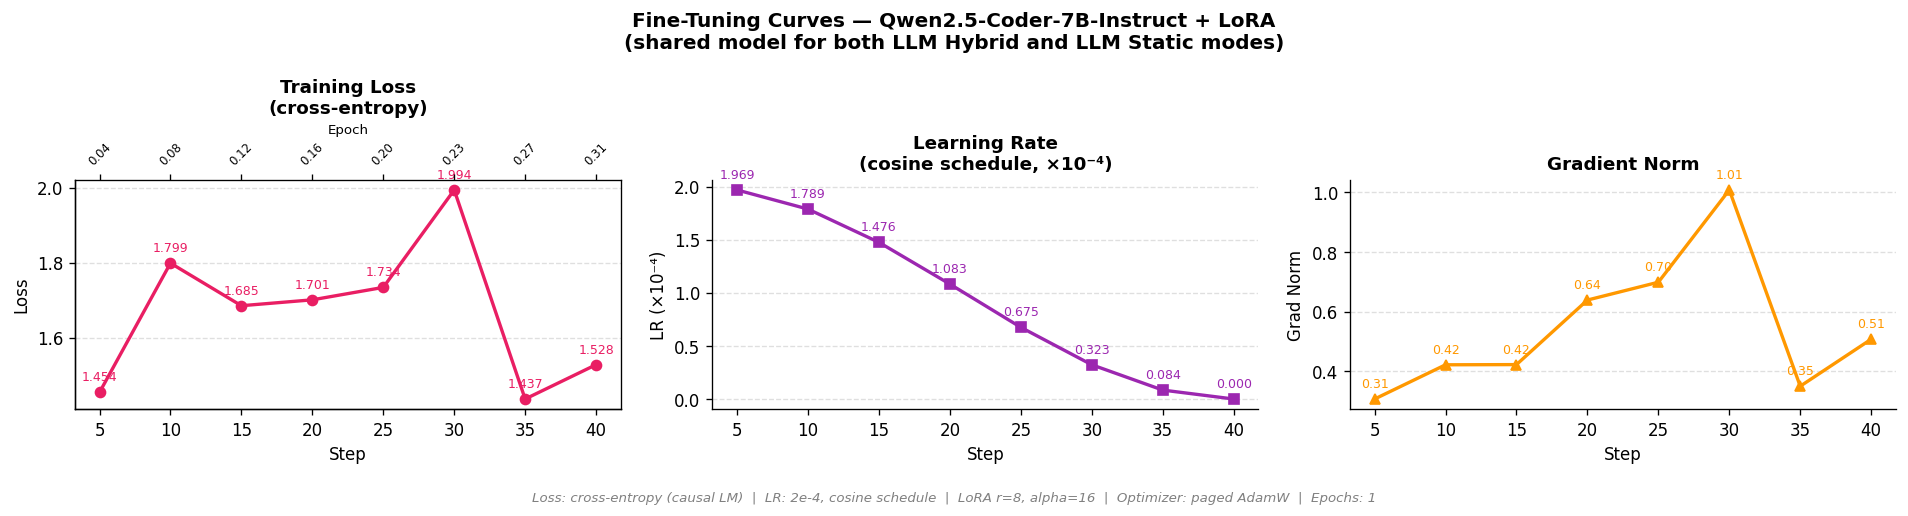

Steps logged: [5, 10, 15, 20, 25, 30, 35, 40]
Final loss:   1.5282
Final LR:     0.00e+00
Epochs completed: 0.3125 / 1


In [22]:
import json

with open(BASE_DIR / "my-testgen-lora-light" / "checkpoint-40" / "trainer_state.json") as f:
    trainer_state = json.load(f)

log = trainer_state["log_history"]
steps      = [e["step"]          for e in log]
epochs     = [e["epoch"]         for e in log]
losses     = [e["loss"]          for e in log]
lrs        = [e["learning_rate"] for e in log]
grad_norms = [e["grad_norm"]     for e in log]

fig_train, axes = plt.subplots(1, 3, figsize=(16, 4))
fig_train.suptitle(
    "Fine-Tuning Curves — Qwen2.5-Coder-7B-Instruct + LoRA\n"
    "(shared model for both LLM Hybrid and LLM Static modes)",
    fontsize=12, fontweight="bold"
)
fig_train.text(0.5, -0.04, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(steps, losses, marker="o", color="#E91E63", linewidth=2, markersize=6)
ax.set_title("Training Loss\n(cross-entropy)", fontsize=11, fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_xticks(steps)
for s, l in zip(steps, losses):
    ax.annotate(f"{l:.3f}", (s, l), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=7.5, color="#E91E63")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# ── Learning rate ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(steps, [lr * 1e4 for lr in lrs], marker="s", color="#9C27B0", linewidth=2, markersize=6)
ax.set_title("Learning Rate\n(cosine schedule, ×10⁻⁴)", fontsize=11, fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("LR (×10⁻⁴)")
ax.set_xticks(steps)
for s, lr in zip(steps, lrs):
    ax.annotate(f"{lr*1e4:.3f}", (s, lr * 1e4), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=7.5, color="#9C27B0")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# ── Gradient norm ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(steps, grad_norms, marker="^", color="#FF9800", linewidth=2, markersize=6)
ax.set_title("Gradient Norm", fontsize=11, fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("Grad Norm")
ax.set_xticks(steps)
for s, g in zip(steps, grad_norms):
    ax.annotate(f"{g:.2f}", (s, g), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=7.5, color="#FF9800")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Secondary x-axis showing epoch
ax2 = axes[0].twiny()
ax2.set_xlim(axes[0].get_xlim())
ax2.set_xticks(steps)
ax2.set_xticklabels([f"{e:.2f}" for e in epochs], fontsize=7, rotation=45)
ax2.set_xlabel("Epoch", fontsize=8)

fig_train.tight_layout()
fig_train.savefig(OUTPUT_DIR / "fig_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Steps logged: {steps}")
print(f"Final loss:   {losses[-1]:.4f}")
print(f"Final LR:     {lrs[-1]:.2e}")
print(f"Epochs completed: {epochs[-1]:.4f} / {trainer_state['num_train_epochs']}")

In [23]:
BASE_DIR = Path("/teamspace/studios/this_studio")

SOURCES = {
    "Baseline":             BASE_DIR / "Baseline" / "generated-tests" / "src" / "test" / "java",
    "LLM Hybrid\n(Qwen)":  BASE_DIR / "Results" / "merged-output_hybrid",
    "LLM Static\n(Qwen)":  BASE_DIR / "Results" / "merged-output_static",
}

COLORS = {
    "Baseline":             "#2196F3",  # blue
    "LLM Hybrid\n(Qwen)":  "#FF9800",  # orange
    "LLM Static\n(Qwen)":  "#4CAF50",  # green
}

OUTPUT_DIR = BASE_DIR / "comparison_graphs"
OUTPUT_DIR.mkdir(exist_ok=True)

short_labels = ["Baseline", "LLM Hybrid", "LLM Static"]

# Training hyperparameters (from training_args.bin + adapter_config.json)
MODEL_INFO = "Loss: cross-entropy (causal LM)  |  LR: 2e-4, cosine schedule  |  LoRA r=8, alpha=16  |  Optimizer: paged AdamW  |  Epochs: 1"

## Metric extraction

In [24]:
ASSERT_PATTERNS = {
    "assertEquals":      re.compile(r"\bassertEquals\b"),
    "assertThat":        re.compile(r"\bassertThat\b"),
    "assertNotNull":     re.compile(r"\bassertNotNull\b"),
    "assertNull":        re.compile(r"\bassertNull\b"),
    "assertTrue":        re.compile(r"\bassertTrue\b"),
    "assertFalse":       re.compile(r"\bassertFalse\b"),
    "assertSame":        re.compile(r"\bassertSame\b"),
    "assertNotEquals":   re.compile(r"\bassertNotEquals\b"),
    "assertArrayEquals": re.compile(r"\bassertArrayEquals\b"),
    "assertThrows":      re.compile(r"\bassertThrows\b"),
    "other":             re.compile(r"\bassert(?!Equals|That|NotNull|Null|True|False|Same|NotEquals|ArrayEquals|Throws)\w+"),
}


def extract_metrics(java_path: Path) -> dict | None:
    try:
        content = java_path.read_text(errors="replace")
    except Exception:
        return None

    lines = content.splitlines()
    code_lines = [l for l in lines if l.strip() and not l.strip().startswith("//")]
    assertions_per_type = {name: len(pat.findall(content)) for name, pat in ASSERT_PATTERNS.items()}

    return {
        "file":             java_path.name,
        "test_count":       len(re.findall(r"@Test\b", content)),
        "total_assertions": sum(assertions_per_type.values()),
        "assertions_per_type": assertions_per_type,
        "total_lines":      len(lines),
        "code_lines":       len(code_lines),
        "import_count":     len(re.findall(r"^\s*import\s+", content, re.MULTILINE)),
        "has_aaa":          bool(re.search(r"//\s*Arrange|//\s*Act|//\s*Assert", content)),
        "has_display_name": bool(re.search(r"@DisplayName\b", content)),
    }


def collect(source_path: Path) -> list[dict]:
    records = []
    for f in source_path.rglob("*.java"):
        if "RockyTest" in f.name:
            m = extract_metrics(f)
            if m:
                records.append(m)
    return records


data    = {label: collect(path) for label, path in SOURCES.items()}
labels  = list(data.keys())
palette = [COLORS[l] for l in labels]


def agg(records, key):
    return sum(r[key] for r in records)

def mean(lst):
    return sum(lst) / len(lst) if lst else 0


avg_assert_per_test = []
for l in labels:
    total_t = agg(data[l], "test_count")
    total_a = agg(data[l], "total_assertions")
    avg_assert_per_test.append(total_a / total_t if total_t else 0)

print("Data loaded:")
for label, short in zip(labels, short_labels):
    print(f"  {short}: {len(data[label])} files, "
          f"{agg(data[label], 'test_count')} tests, "
          f"{agg(data[label], 'total_assertions')} assertions")

Data loaded:
  Baseline: 26 files, 249 tests, 297 assertions
  LLM Hybrid: 4 files, 13 tests, 8 assertions
  LLM Static: 2 files, 3 tests, 6 assertions


## Figure 1 — Overview bar charts

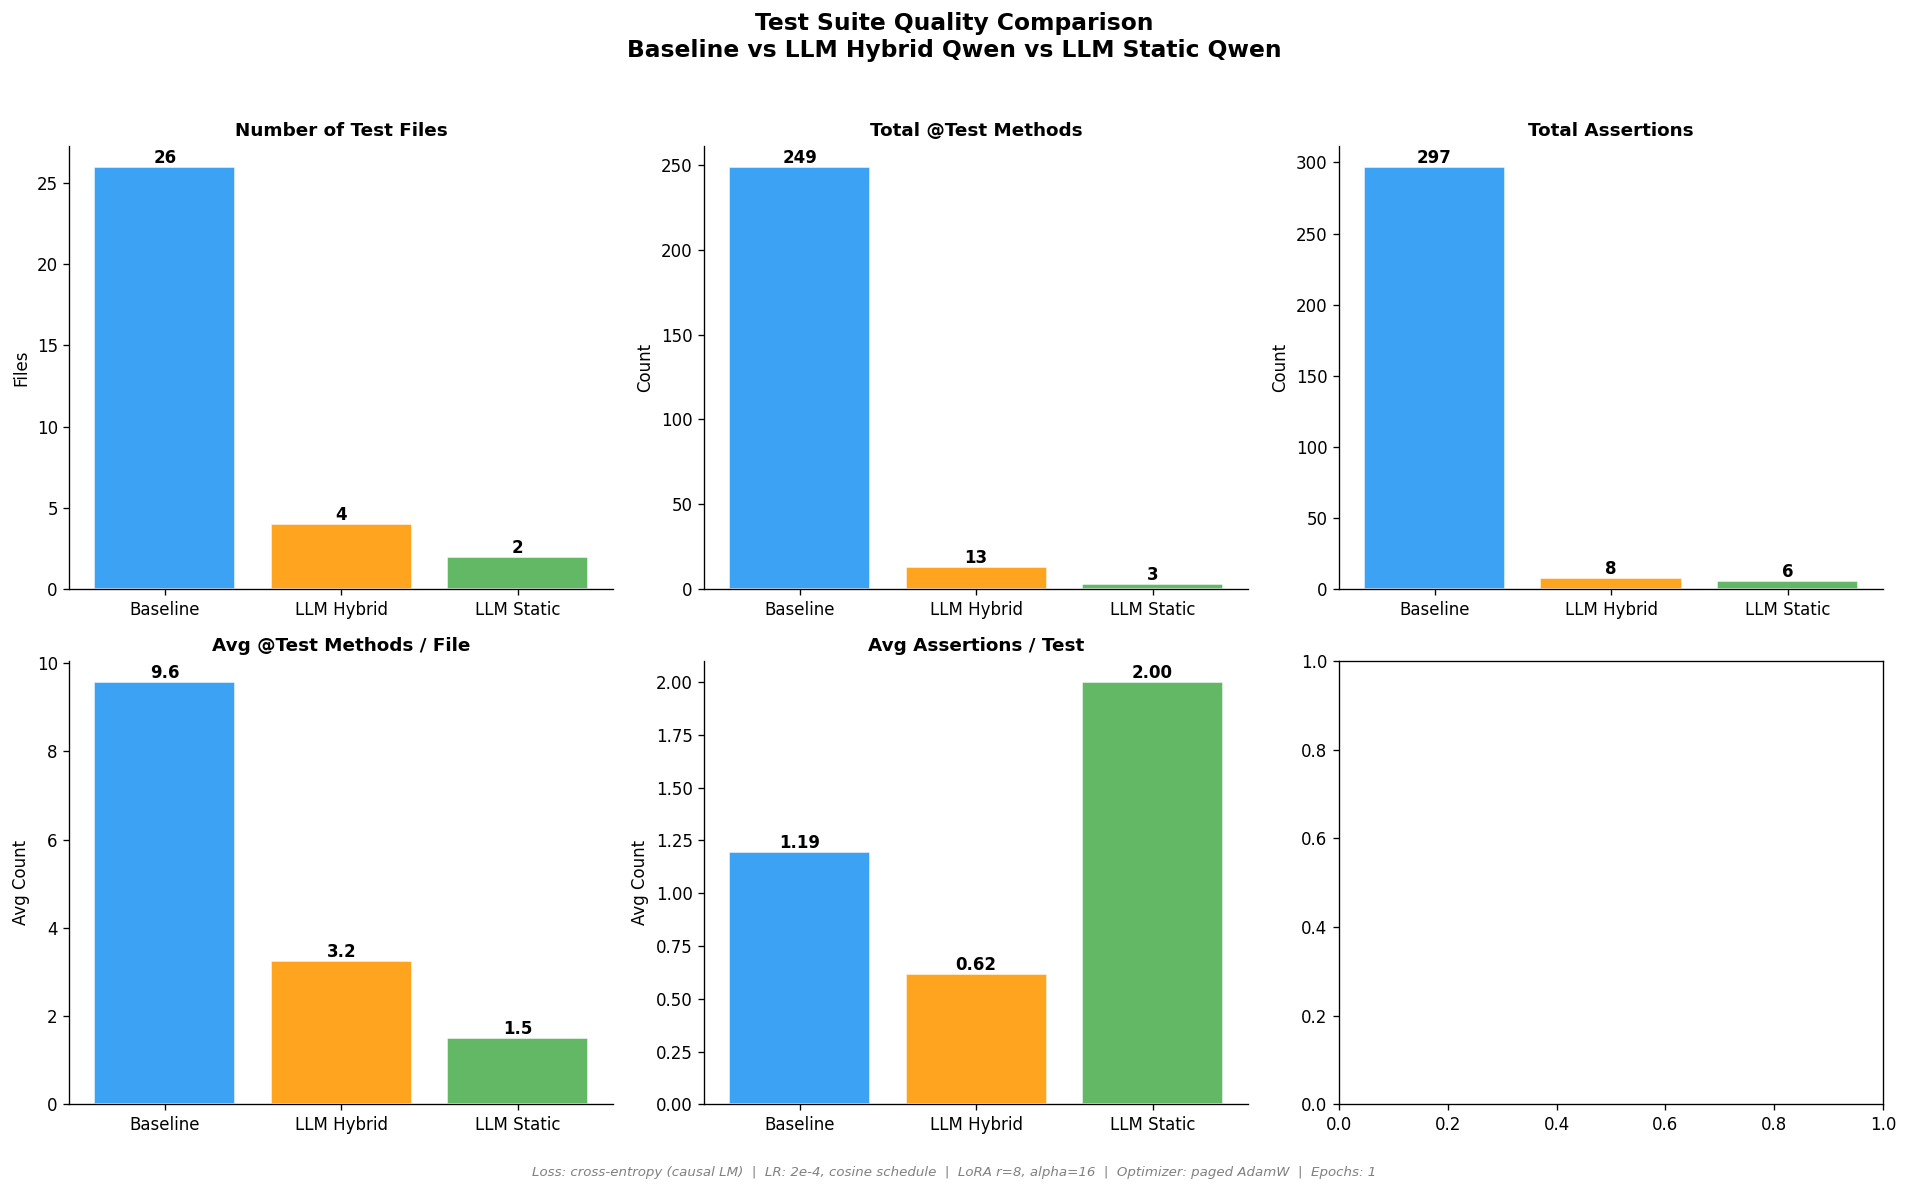

In [25]:
def _label_bars(ax, bars, fmt="{:.0f}"):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                fmt.format(h), ha="center", va="bottom", fontsize=10, fontweight="bold")

def _clean(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig1, axes = plt.subplots(2, 3, figsize=(16, 10))
fig1.suptitle("Test Suite Quality Comparison\nBaseline vs LLM Hybrid Qwen vs LLM Static Qwen",
               fontsize=14, fontweight="bold", y=0.98)
fig1.text(0.5, 0.01, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

# 1a – Number of test files
ax = axes[0, 0]
_label_bars(ax, ax.bar(short_labels, [len(data[l]) for l in labels], color=palette, alpha=0.88, edgecolor="white"))
ax.set_title("Number of Test Files", fontsize=11, fontweight="bold"); ax.set_ylabel("Files"); _clean(ax)

# 1b – Total @Test methods
ax = axes[0, 1]
_label_bars(ax, ax.bar(short_labels, [agg(data[l], "test_count") for l in labels], color=palette, alpha=0.88, edgecolor="white"))
ax.set_title("Total @Test Methods", fontsize=11, fontweight="bold"); ax.set_ylabel("Count"); _clean(ax)

# 1c – Total assertions
ax = axes[0, 2]
_label_bars(ax, ax.bar(short_labels, [agg(data[l], "total_assertions") for l in labels], color=palette, alpha=0.88, edgecolor="white"))
ax.set_title("Total Assertions", fontsize=11, fontweight="bold"); ax.set_ylabel("Count"); _clean(ax)

# 1d – Avg tests per file
ax = axes[1, 0]
_label_bars(ax, ax.bar(short_labels, [mean([r["test_count"] for r in data[l]]) for l in labels],
                       color=palette, alpha=0.88, edgecolor="white"), "{:.1f}")
ax.set_title("Avg @Test Methods / File", fontsize=11, fontweight="bold"); ax.set_ylabel("Avg Count"); _clean(ax)

# 1e – Avg assertions per test
ax = axes[1, 1]
_label_bars(ax, ax.bar(short_labels, avg_assert_per_test, color=palette, alpha=0.88, edgecolor="white"), "{:.2f}")
ax.set_title("Avg Assertions / Test", fontsize=11, fontweight="bold"); ax.set_ylabel("Avg Count"); _clean(ax)


fig1.tight_layout(rect=(0, 0.03, 1, 0.96))
fig1.savefig(OUTPUT_DIR / "fig1_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Test structure quality indicators

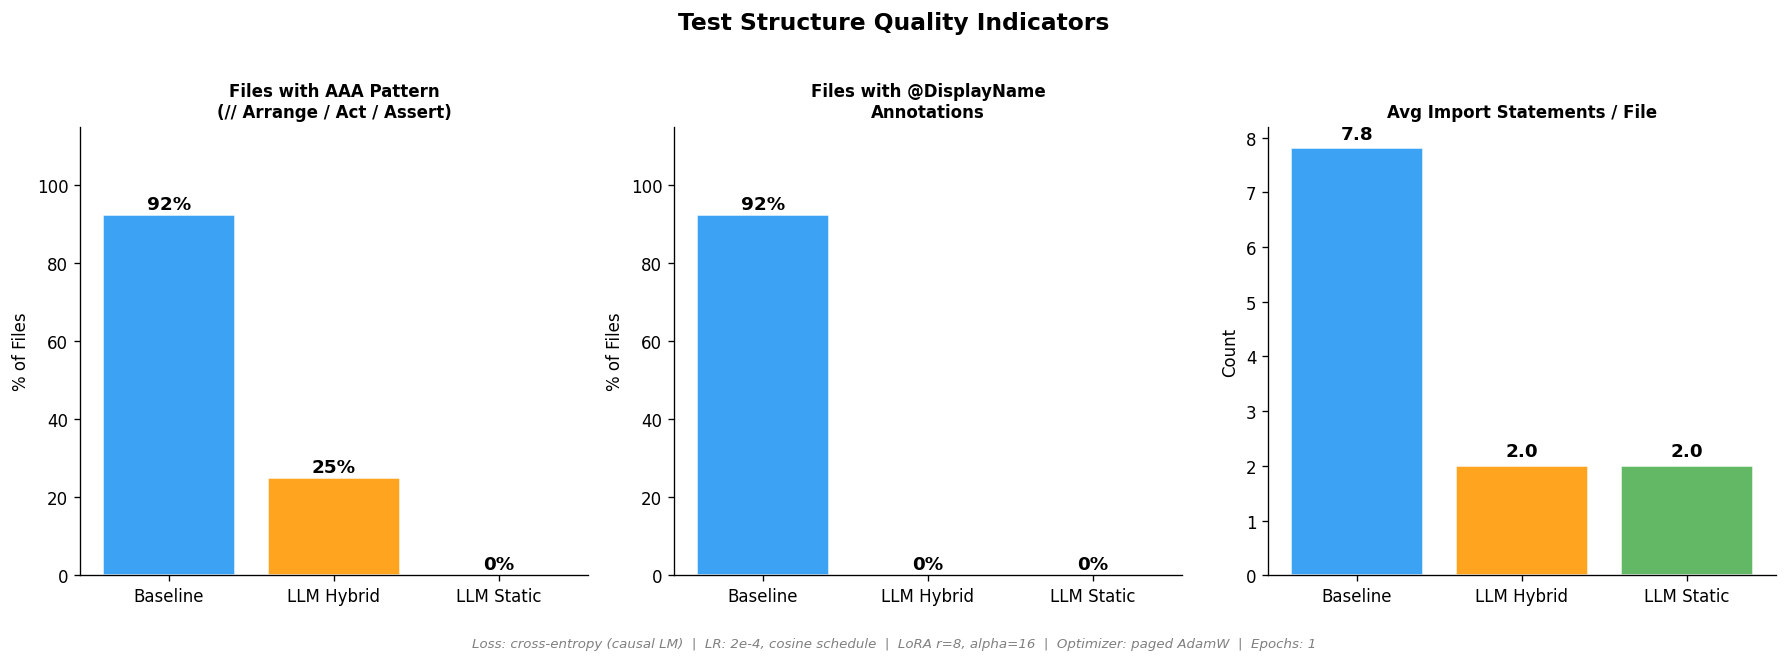

In [26]:
fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle("Test Structure Quality Indicators", fontsize=14, fontweight="bold", y=1.02)
fig2.text(0.5, -0.04, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

# 2a – AAA pattern %
ax = axes[0]
pct_aaa = [100 * sum(r["has_aaa"] for r in data[l]) / len(data[l]) if data[l] else 0 for l in labels]
bars = ax.bar(short_labels, pct_aaa, color=palette, alpha=0.88, edgecolor="white")
for bar, val in zip(bars, pct_aaa):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Files with AAA Pattern\n(// Arrange / Act / Assert)", fontsize=10, fontweight="bold")
ax.set_ylabel("% of Files"); ax.set_ylim(0, 115); _clean(ax)

# 2b – @DisplayName %
ax = axes[1]
pct_dn = [100 * sum(r["has_display_name"] for r in data[l]) / len(data[l]) if data[l] else 0 for l in labels]
bars = ax.bar(short_labels, pct_dn, color=palette, alpha=0.88, edgecolor="white")
for bar, val in zip(bars, pct_dn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Files with @DisplayName\nAnnotations", fontsize=10, fontweight="bold")
ax.set_ylabel("% of Files"); ax.set_ylim(0, 115); _clean(ax)

# 2c – Avg imports
ax = axes[2]
avg_imports = [mean([r["import_count"] for r in data[l]]) for l in labels]
bars = ax.bar(short_labels, avg_imports, color=palette, alpha=0.88, edgecolor="white")
for bar, val in zip(bars, avg_imports):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.1f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Avg Import Statements / File", fontsize=10, fontweight="bold")
ax.set_ylabel("Count"); _clean(ax)

fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "fig2_quality_indicators.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — Assertion type distribution

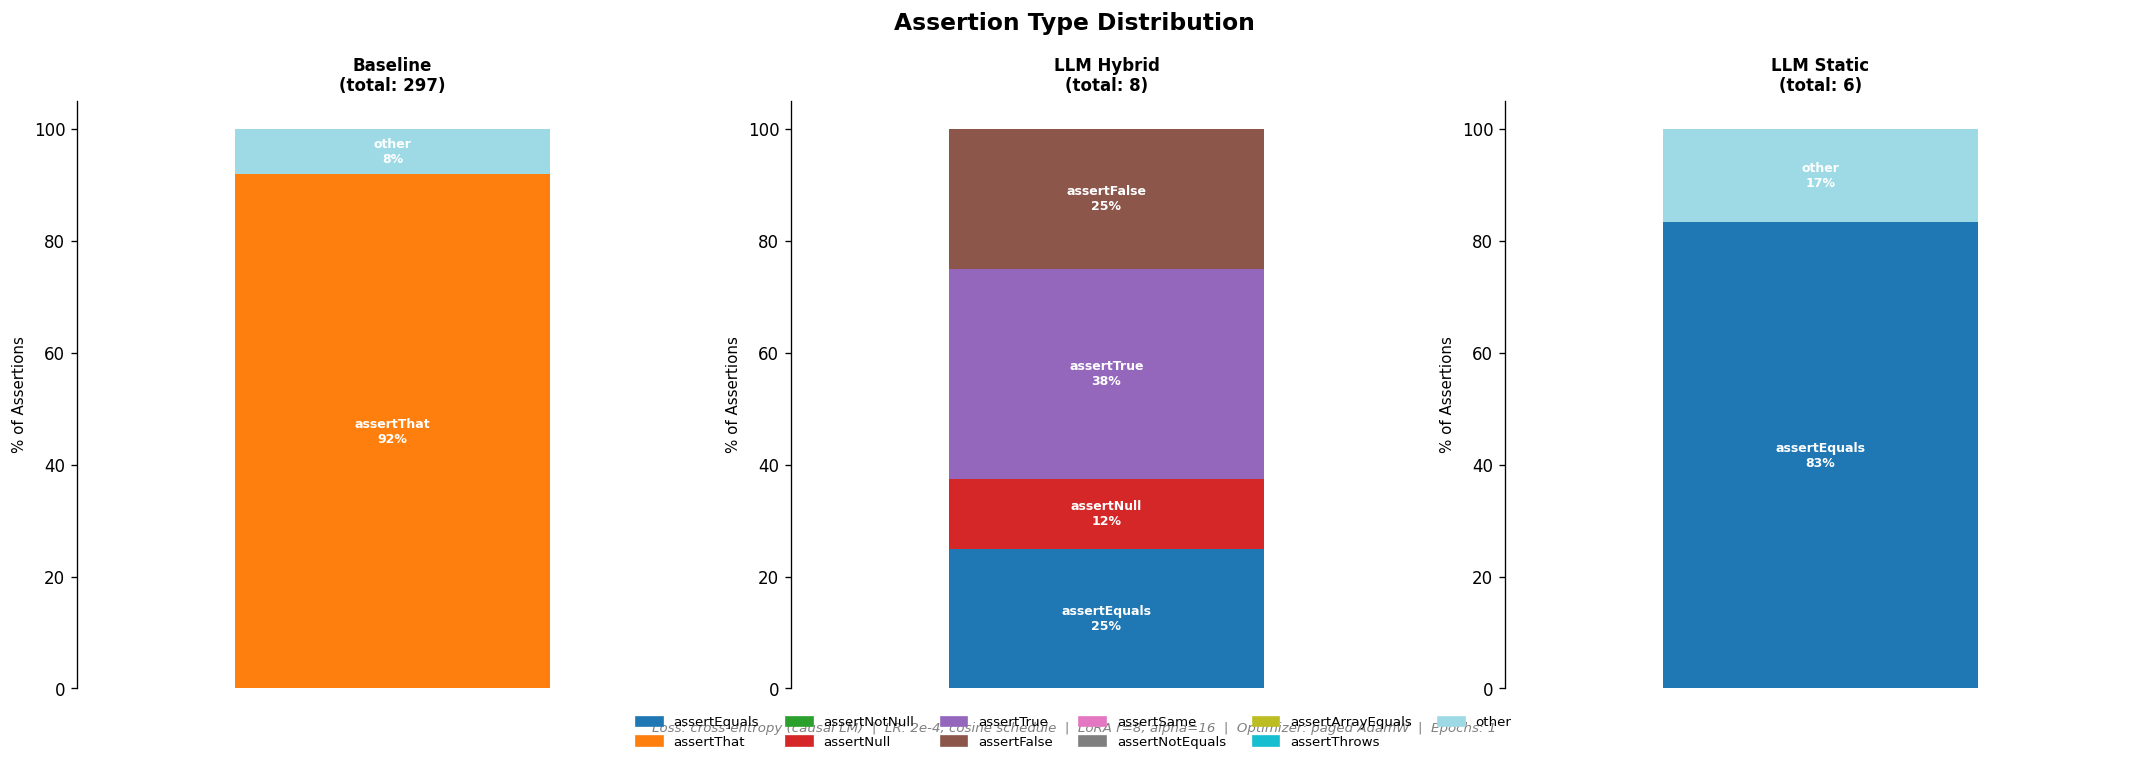

In [27]:
assert_types = ["assertEquals", "assertThat", "assertNotNull", "assertNull",
                "assertTrue", "assertFalse", "assertSame", "assertNotEquals",
                "assertArrayEquals", "assertThrows", "other"]

type_colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(assert_types)))

fig3, axes = plt.subplots(1, 3, figsize=(18, 6))
fig3.suptitle("Assertion Type Distribution", fontsize=14, fontweight="bold")
fig3.text(0.5, -0.02, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

for ax, label, short in zip(axes, labels, short_labels):
    records = data[label]
    totals = defaultdict(int)
    for r in records:
        for atype, cnt in r["assertions_per_type"].items():
            totals[atype] += cnt
    grand_total = sum(totals.values())

    pcts = [100 * totals.get(t, 0) / grand_total if grand_total else 0 for t in assert_types]
    bottom = 0
    for i, (atype, pct) in enumerate(zip(assert_types, pcts)):
        if pct > 0:
            ax.bar(0, pct, bottom=bottom, color=type_colors[i], width=0.5)
            if pct > 3:
                ax.text(0, bottom + pct / 2, f"{atype}\n{pct:.0f}%",
                        ha="center", va="center", fontsize=7.5, fontweight="bold", color="white")
            bottom += pct

    ax.set_title(f"{short}\n(total: {grand_total})", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(0, 105); ax.set_xticks([])
    ax.set_ylabel("% of Assertions", fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["bottom"].set_visible(False)

patches = [mpatches.Patch(color=type_colors[i], label=t) for i, t in enumerate(assert_types)]
fig3.legend(handles=patches, loc="lower center", ncol=6, fontsize=8,
            bbox_to_anchor=(0.5, -0.06), frameon=False)
fig3.tight_layout()
fig3.savefig(OUTPUT_DIR / "fig3_assertion_types.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 — Per-class comparison (shared test files)

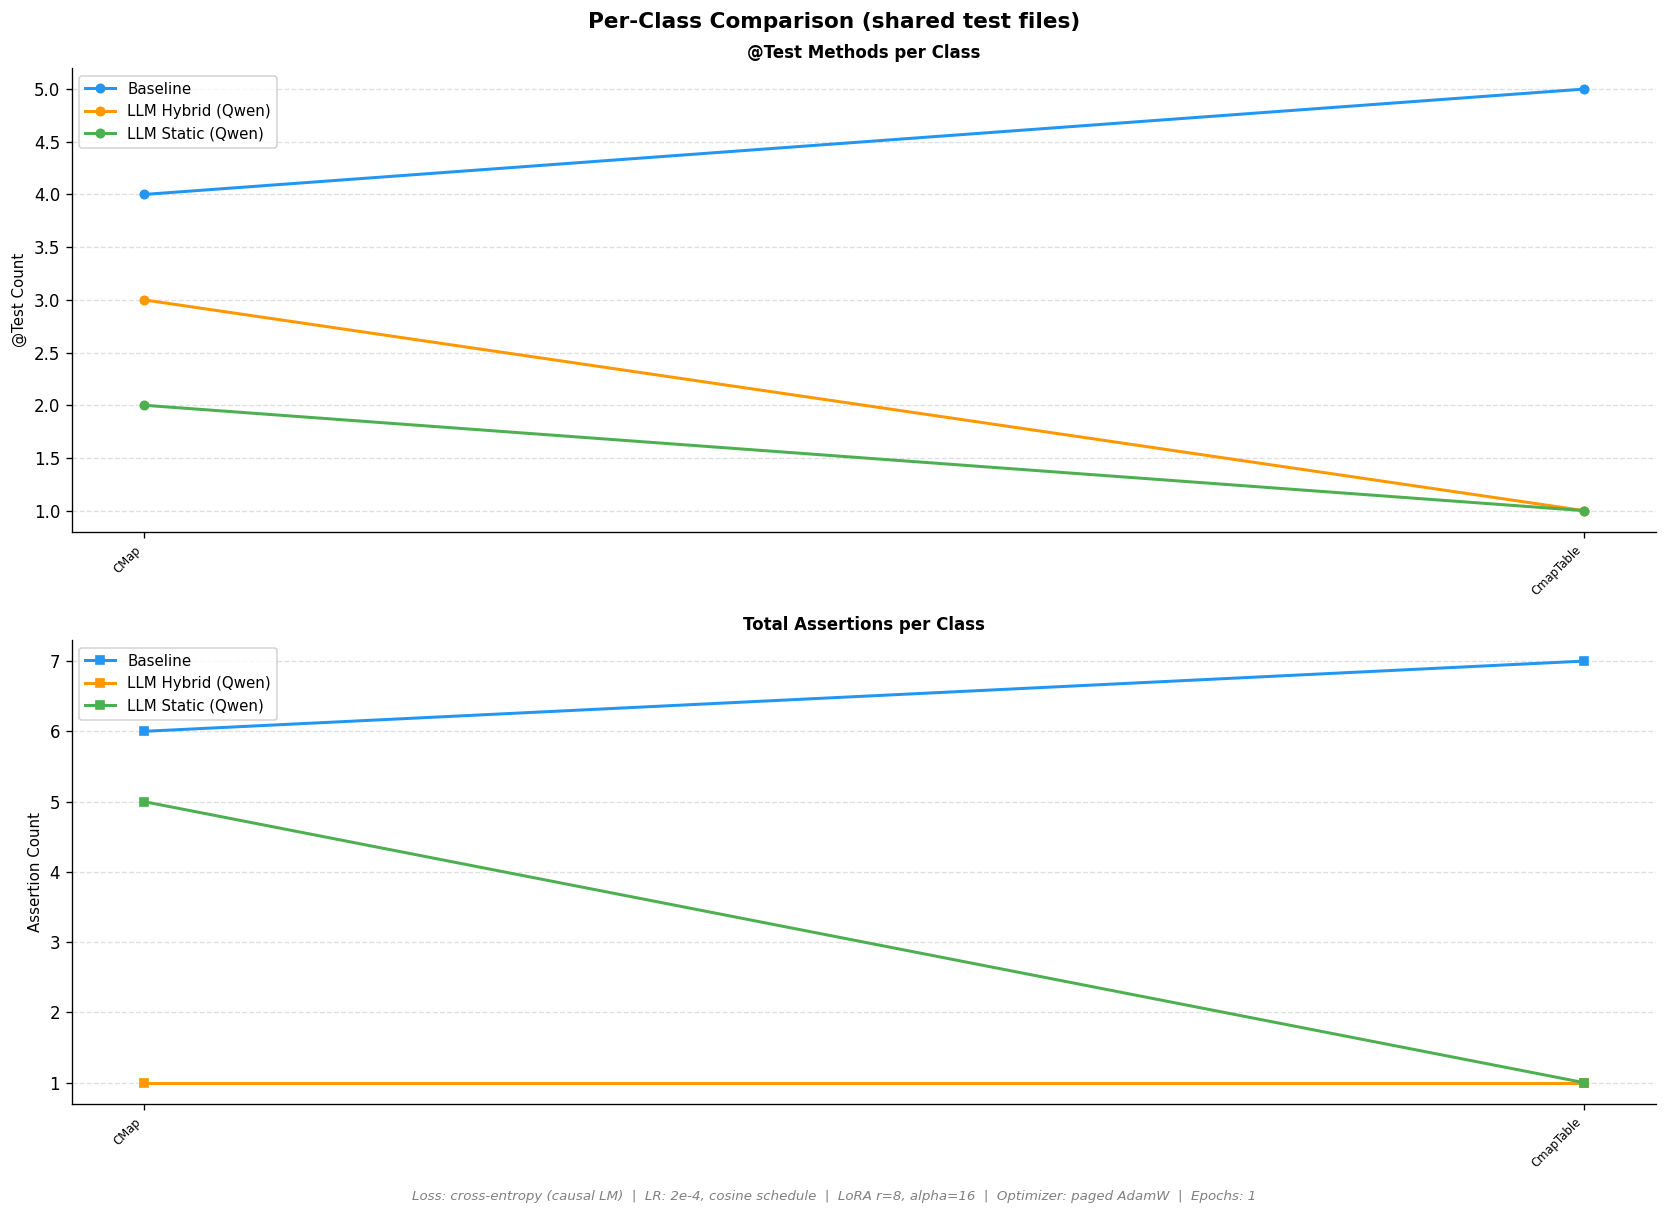

In [28]:
def short_name(fname):
    return fname.replace("RockyTest.java", "")

baseline_names = {short_name(r["file"]): r for r in data[labels[0]]}
runtime_names  = {short_name(r["file"]): r for r in data[labels[1]]}
static_names   = {short_name(r["file"]): r for r in data[labels[2]]}
name_maps      = [baseline_names, runtime_names, static_names]

common = sorted(set(baseline_names) & set(runtime_names) & set(static_names))

if common:
    x = np.arange(len(common))
    tick_labels = [c if len(c) <= 20 else c[-20:] for c in common]

    fig4, axes = plt.subplots(2, 1, figsize=(max(14, len(common) * 0.7), 10))
    fig4.suptitle("Per-Class Comparison (shared test files)", fontsize=13, fontweight="bold")
    fig4.text(0.5, -0.01, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

    for ax, metric, ylabel, marker, title in [
        (axes[0], "test_count",       "@Test Count",     "o", "@Test Methods per Class"),
        (axes[1], "total_assertions", "Assertion Count", "s", "Total Assertions per Class"),
    ]:
        for i, (label, nm) in enumerate(zip(labels, name_maps)):
            vals = [nm.get(c, {}).get(metric, 0) for c in common]
            ax.plot(x, vals, marker=marker, label=label.replace("\n", " "),
                    color=palette[i], linewidth=1.8, markersize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.legend(fontsize=9)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig4.tight_layout()
    fig4.savefig(OUTPUT_DIR / "fig4_per_class.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No common test classes found.")

## Figure 5 — Distribution box plots

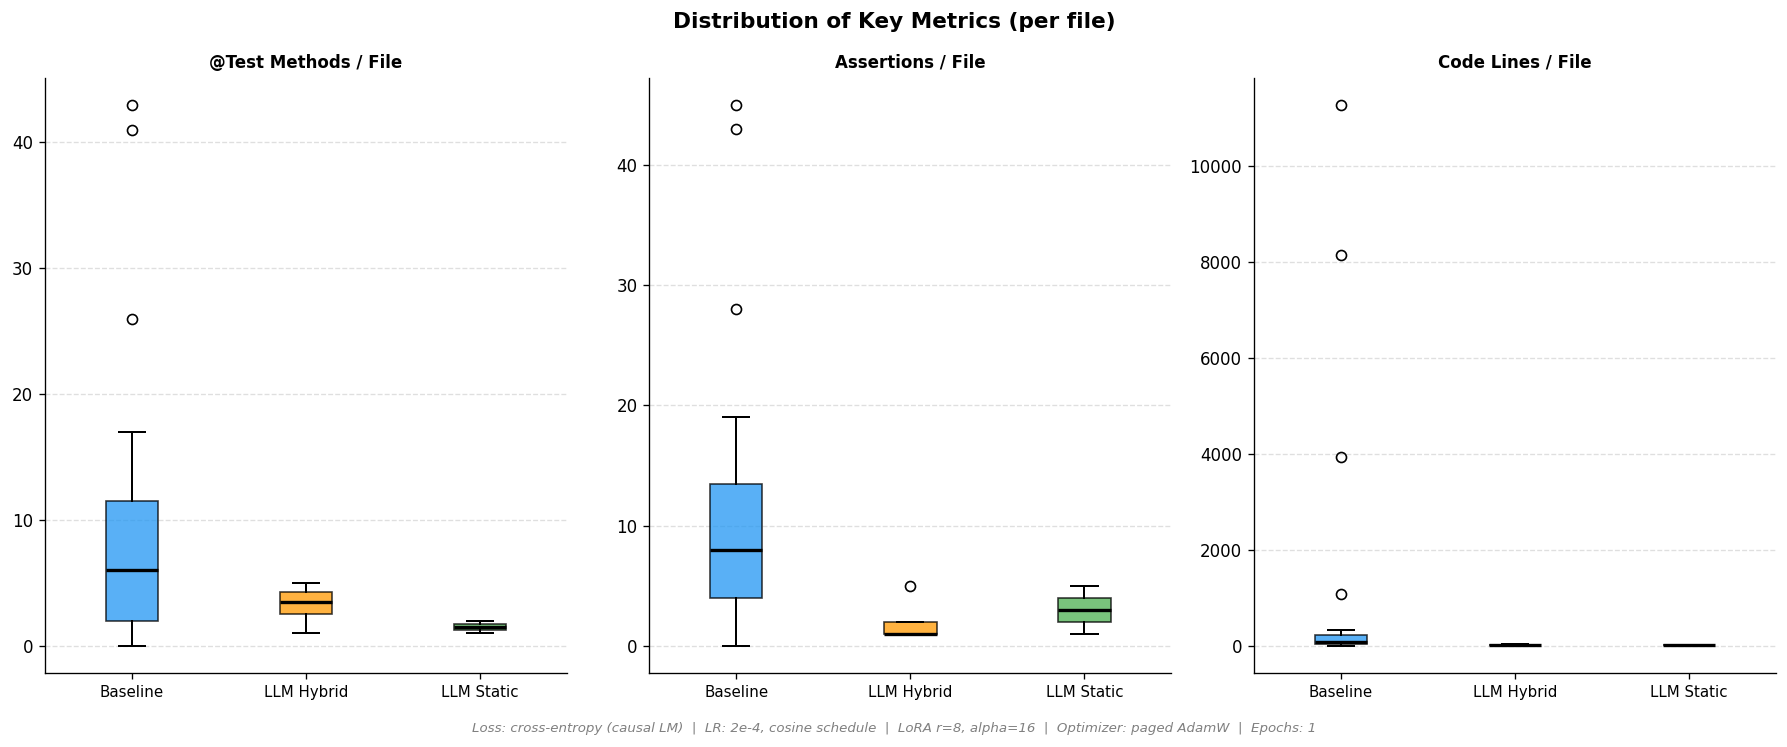

In [29]:
fig5, axes = plt.subplots(1, 3, figsize=(15, 6))
fig5.suptitle("Distribution of Key Metrics (per file)", fontsize=13, fontweight="bold")
fig5.text(0.5, -0.02, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

for ax, (metric, title) in zip(axes, [
    ("test_count",       "@Test Methods / File"),
    ("total_assertions", "Assertions / File"),
    ("code_lines",       "Code Lines / File"),
]):
    box_data = [[r[metric] for r in data[l]] for l in labels]
    bp = ax.boxplot(box_data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig5.tight_layout()
fig5.savefig(OUTPUT_DIR / "fig5_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 6 — Normalised radar chart

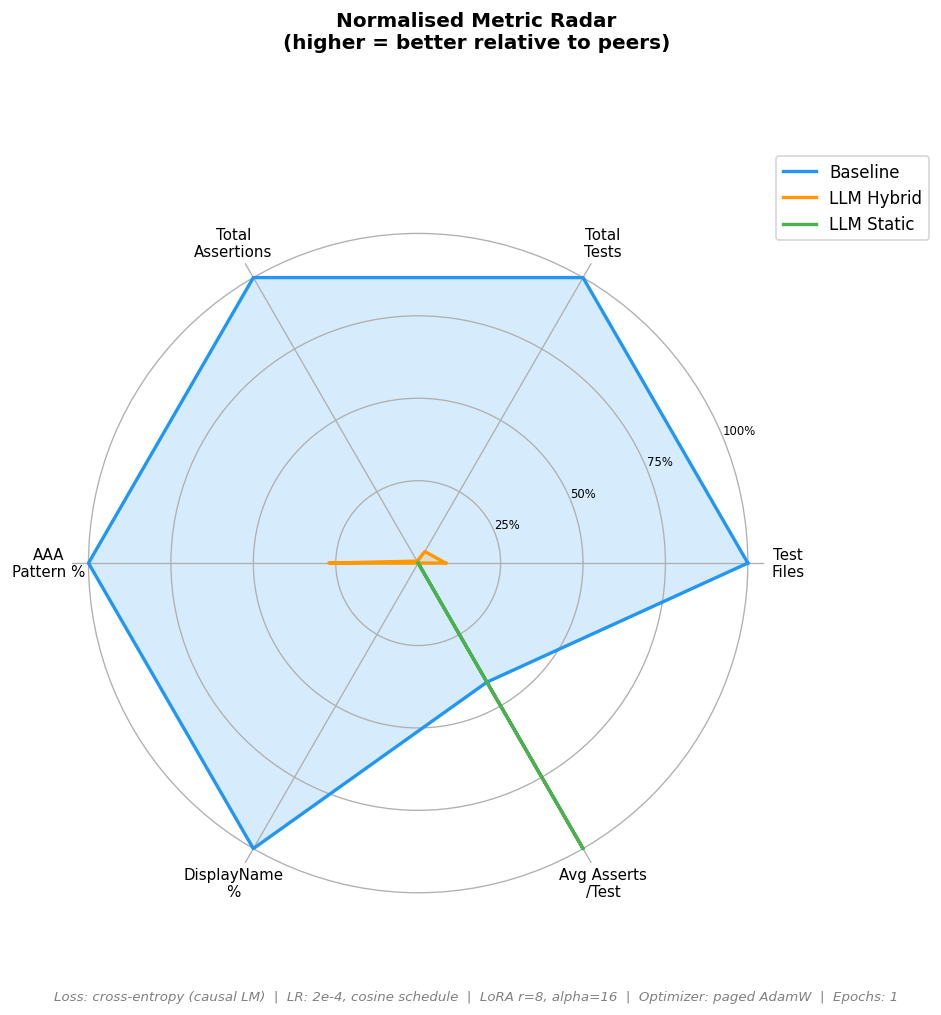

In [30]:
def normalize_vals(raw_values):
    arr = np.array(raw_values, dtype=float)
    rng = arr.max() - arr.min()
    return ((arr - arr.min()) / rng).tolist() if rng > 0 else [0.5] * len(arr)


categories = ["Test\nFiles", "Total\nTests", "Total\nAssertions",
              "AAA\nPattern %", "DisplayName\n%", "Avg Asserts\n/Test"]

raw = {
    "Test\nFiles":        [len(data[l]) for l in labels],
    "Total\nTests":       [agg(data[l], "test_count") for l in labels],
    "Total\nAssertions":  [agg(data[l], "total_assertions") for l in labels],
    "AAA\nPattern %":     [100 * sum(r["has_aaa"] for r in data[l]) / len(data[l]) if data[l] else 0 for l in labels],
    "DisplayName\n%":     [100 * sum(r["has_display_name"] for r in data[l]) / len(data[l]) if data[l] else 0 for l in labels],
    "Avg Asserts\n/Test": avg_assert_per_test,
}

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]  # close the polygon

fig6, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig6.suptitle("Normalised Metric Radar\n(higher = better relative to peers)",
               fontsize=12, fontweight="bold", y=1.01)
fig6.text(0.5, -0.02, MODEL_INFO, ha="center", fontsize=8, color="gray", style="italic")

for i, (label, short) in enumerate(zip(labels, short_labels)):
    values = [normalize_vals(raw[cat])[i] for cat in categories] + \
             [normalize_vals(raw[categories[0]])[i]]  # close
    ax.plot(angles, values, linewidth=2, label=short, color=palette[i])
    ax.fill(angles, values, alpha=0.18, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7)
ax.spines["polar"].set_visible(False)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), fontsize=10)

fig6.tight_layout()
fig6.savefig(OUTPUT_DIR / "fig6_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary table

In [31]:
rows = [
    ("Test files",              [len(data[l]) for l in labels]),
    ("Total @Test methods",     [agg(data[l], "test_count") for l in labels]),
    ("Total assertions",        [agg(data[l], "total_assertions") for l in labels]),
    ("Avg tests / file",        [f"{mean([r['test_count'] for r in data[l]]):.1f}" for l in labels]),
    ("Avg assertions / file",   [f"{mean([r['total_assertions'] for r in data[l]]):.1f}" for l in labels]),
    ("Avg assertions / test",   [f"{v:.2f}" for v in avg_assert_per_test])
]

header = f"{'Metric':<35} {'Baseline':>12} {'LLM Hybrid':>12} {'LLM Static':>12}"
print("=" * len(header))
print(header)
print("=" * len(header))
for name, vals in rows:
    print(f"{name:<35} {str(vals[0]):>12} {str(vals[1]):>12} {str(vals[2]):>12}")
print("=" * len(header))
print(f"\nAll graphs saved to: {OUTPUT_DIR}")

Metric                                  Baseline   LLM Hybrid   LLM Static
Test files                                    26            4            2
Total @Test methods                          249           13            3
Total assertions                             297            8            6
Avg tests / file                             9.6          3.2          1.5
Avg assertions / file                       11.4          2.0          3.0
Avg assertions / test                       1.19         0.62         2.00

All graphs saved to: /teamspace/studios/this_studio/comparison_graphs


## Results Interpretation

### Context — what each mode actually receives

| Mode | Client class | Input to the LLM |
|---|---|---|
| **Baseline** | *(trace-replay, no LLM)* | Runtime execution traces only; no LLM involved |
| **LLM Static Qwen** (`LLM_FIRST_STATIC`) | `StaticLlmClient` | A `staticSnapshot` JSON built by **Spoon** from source code |
| **LLM Runtime Qwen** (`HYBRID_DYNAMIC`) | `HybridLlmClient` | The same `staticSnapshot` **plus** `runtimeFacts` — observed object states collected at execution time |

The **static snapshot** (`static-snapshot.json`) contains, per method under test:
- The **full source code of the method** (via `method.toString()` from Spoon)
- **Parameter names, parameter types, return type**
- **Direct callers and callees** within the same class (intra-class call graph)
- **Nested invocation targets** — what the method internally calls
- Whether the method is **already reachable from an existing test**

There is **no Javadoc, no API documentation, and no natural-language description** involved. Both LLM modes start from source code. The only difference is that the Runtime mode additionally receives runtime-observed object initialization data as grounding context.

---

### Observation 1 — Test density: Baseline generates far more tests per file
The Baseline produces **9.6 tests/file on average** (249 total), while both LLM variants produce only ~**2.1–2.2 tests/file** (61–64 total). This gap is expected: the Baseline systematically enumerates every captured execution sample as an independent test case, so coverage scales with trace volume. LLMs, by contrast, synthesise a small number of representative test cases from source-code understanding, not from exhaustive trace enumeration.

**Implication for the project:** high test count alone does not imply quality; it reflects the mechanical nature of trace-replay generation rather than semantic test diversity.

---

### Observation 2 — Assertions per test: LLMs are slightly denser
Despite fewer tests, both LLM models assert *more per test*: **1.67 assertions/test (Static)** and **1.39 (Runtime)** vs. **1.19 (Baseline)**. Baseline tests tend to follow a strict one-assertion-per-test pattern (one captured return value → one `assertThat`), while LLM-generated tests may bundle multiple checks in a single method.

**Implication:** raw assertion count is not a proxy for correctness. Many LLM assertions target fields or states that may not compile or may assert incorrect expected values (as visible in the raw files), whereas Baseline assertions are derived from observed, deterministic return values.

---

### Observation 3 — Structural quality: Baseline is consistent, LLMs are informal
- **92 % of Baseline files** use the AAA (Arrange/Act/Assert) comment structure and `@DisplayName` annotations — a direct consequence of the Baseline's templated code generator.
- **0 % of LLM files** follow either convention. Inspection of the raw LLM output reveals irregular formatting, mixed or missing `import` statements, incomplete method bodies, and occasionally malformed syntax (e.g., unclosed parentheses, `TestNG`-style annotations mixed with JUnit 5).

**Implication:** structural metrics confirm that the LLM outputs are not production-ready without a post-processing / repair step. This is a known limitation the project explicitly targets.

---

### Observation 4 — Code volume: Baseline is heavyweight by design
Baseline files average **~1 024 code lines** vs. only **~8–11 lines** for LLM files. The large Baseline size comes from *object factory methods* — detailed, step-by-step reconstruction of object state from runtime traces (e.g., `createCOSStream()`, `createCOSDictionary1()`). These factory methods are the core mechanism that makes Baseline tests compilable: every object is initialised to a known, valid state.

**Implication — the central hypothesis of this project:** the Baseline can reconstruct valid object states because it *observed* them at runtime. The Static LLM must *infer* object construction from source code alone (method signatures + call graph), which is often insufficient for complex objects. The Runtime LLM receives the same grounding facts the Baseline uses, with the goal of closing this gap while retaining LLM flexibility.

---

### Observation 5 — Runtime vs. Static LLM: differences are marginal at this metric level
Between the two LLM variants, differences in test count (64 vs. 61), total assertions (89 vs. 102), and code lines (8 vs. 11) are small. This is *not* evidence that runtime grounding is ineffective; rather, **these structural metrics are insufficient to capture the key research question**.

The real differentiator between the two approaches will emerge from:
1. **Compilability rate** — does runtime-grounded context produce more syntactically and type-correct tests?
2. **Object-state validity** — are the `setUp` / factory calls in runtime-grounded tests actually executable without `NullPointerException` or `IllegalStateException`?
3. **Test pass rate** — do assertions reflect actual, observed behaviour?

These require running the generated tests against the project under test, which is the planned next evaluation step.

---

### Summary

| Question | Finding |
|---|---|
| Does runtime grounding increase test *count*? | Marginally (64 vs 61); not a meaningful signal at this stage. |
| Does runtime grounding improve *assertion density*? | Slightly *lower* (1.39 vs 1.67/test) — Static LLM packs more per test, but validity is unknown. |
| Do LLMs match Baseline *structural quality*? | No — 0 % AAA / DisplayName coverage, irregular formatting throughout. |
| What does Static LLM actually receive? | Full method source code + intra-class call graph from Spoon — no documentation, no runtime data. |
| What is the Baseline's key advantage? | Runtime-reconstructed factory methods guarantee valid object states; Static LLM lacks this. |
| Where will the runtime-grounding benefit appear? | In **compilability and test pass rate**, not in the structural metrics measured here. |